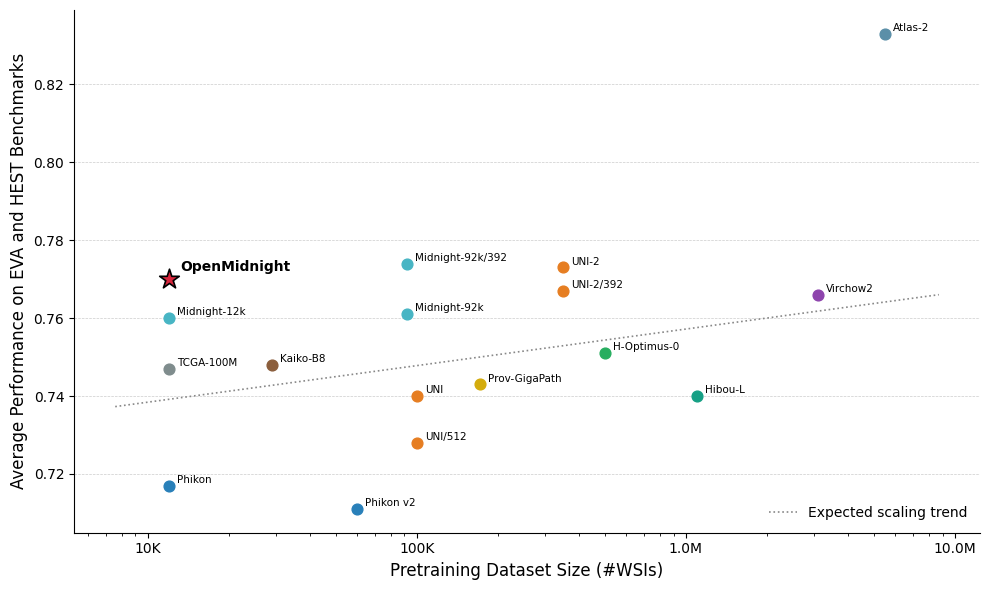

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ============================================================
# DATA — add/edit models here as needed
# Format: 'Model Name': (num_WSIs, avg_performance)
# ============================================================
models = {
    'Midnight-12k':       (12_000,    0.760),
    'Midnight-92k':       (92_000,    0.761),
    'Midnight-92k/392':   (92_000,    0.774),
    'UNI-2':              (350_000,   0.773),
    'UNI-2/392':          (350_000,   0.767),
    'Virchow2':           (3_100_000, 0.766),
    'H-Optimus-0':        (500_000,   0.751),
    'Kaiko-B8':           (29_000,    0.748),
    'TCGA-100M':          (12_000,    0.747),
    'Prov-GigaPath':      (171_189,   0.743),
    'Hibou-L':            (1_100_000, 0.740),
    'UNI':                (100_000,   0.740),
    'UNI/512':            (100_000,   0.728),
    'Phikon':             (12_000,    0.717),
    'Phikon v2':          (60_000,    0.711),
    'Atlas-2':            (5_500_000, 0.833),
}
our_model = {
    'OpenMidnight': (12_000, 0.770),
}

# ============================================================
# Family color mapping — reserving red exclusively for OpenMidnight,
# so Kaiko/Atlas moved off red-family hues
# ============================================================
FAMILY_COLORS = {
    'Midnight':      '#48B5C4',  # cyan
    'UNI':           '#E67E22',  # orange
    'Virchow':       '#8E44AD',  # purple
    'H-Optimus':     '#27AE60',  # green
    'Kaiko':         '#8B5E3C',  # brown (moved off red)
    'TCGA':          '#7F8C8D',  # gray
    'Prov-GigaPath': '#D4AC0D',  # gold
    'Hibou':         '#16A085',  # teal
    'Phikon':        '#2980B9',  # blue
    'Atlas':         '#5B8FA8',  # steel blue (moved off red)
}

def get_family_color(name):
    for prefix, color in FAMILY_COLORS.items():
        if name.startswith(prefix):
            return color
    return '#999999'  # fallback gray for unmatched

COLOR_OURS = '#D7263D'  # red — reserved for OpenMidnight only

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

for name, (wsis, perf) in models.items():
    color = get_family_color(name)
    ax.scatter(wsis, perf, color=color, s=60, zorder=3)
    ax.annotate(name, (wsis, perf), textcoords='offset points',
            xytext=(6, 2), fontsize=7.5, color='black')

for name, (wsis, perf) in our_model.items():
    ax.scatter(wsis, perf, color=COLOR_OURS, s=220, zorder=6, marker='*',
               edgecolors='black', linewidths=1.2)
    ax.annotate(name, (wsis, perf), textcoords='offset points',
                xytext=(8, 6), fontsize=10, fontweight='bold', color='black')

# --- Expectation line: exclude Atlas-2 (outlier/leverage point) from fit ---
TREND_EXCLUDE = {'Atlas-2'}
trend_models = {k: v for k, v in models.items() if k not in TREND_EXCLUDE}
x_vals = np.array([v[0] for v in trend_models.values()])
y_vals = np.array([v[1] for v in trend_models.values()])
log_x = np.log10(x_vals)
coeffs = np.polyfit(log_x, y_vals, 1)

all_x = [v[0] for v in models.values()] + [v[0] for v in our_model.values()]
x_line = np.logspace(np.log10(min(all_x)) - 0.2,
                      np.log10(max(all_x)) + 0.2, 200)
y_line = coeffs[0] * np.log10(x_line) + coeffs[1]
ax.plot(x_line, y_line, linestyle=':', linewidth=1.2,
        color='#888888', zorder=1, label='Expected scaling trend')

# --- Axes & style ---
ax.set_xscale('log')
ax.set_xlabel('Pretraining Dataset Size (#WSIs)', fontsize=12)
ax.set_ylabel('Average Performance on EVA and HEST Benchmarks', fontsize=12)
ax.tick_params(axis='both', labelsize=10)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}K' if x < 1_000_000 else f'{x/1_000_000:.1f}M'
))
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='gray')
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, frameon=False, loc='lower right')
plt.tight_layout()
plt.savefig('perf_vs_dataset_size.png', dpi=300, bbox_inches='tight')
plt.show()

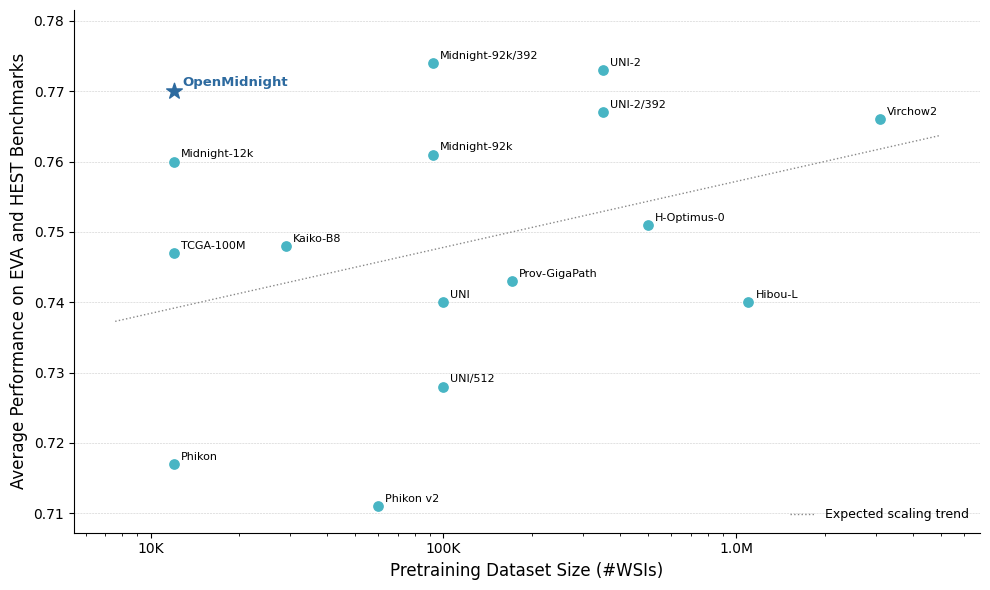

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ============================================================
# DATA — add/edit models here as needed
# Format: 'Model Name': (num_WSIs, avg_performance)
# ============================================================
models = {
    'Midnight-12k':       (12_000,    0.760),
    'Midnight-92k':       (92_000,    0.761),
    'Midnight-92k/392':   (92_000,    0.774),
    'UNI-2':              (350_000,   0.773),
    'UNI-2/392':          (350_000,   0.767),
    'Virchow2':           (3_100_000, 0.766),
    'H-Optimus-0':        (500_000,   0.751),
    'Kaiko-B8':           (29_000,    0.748),
    'TCGA-100M':          (12_000,    0.747),
    'Prov-GigaPath':      (171_189,   0.743),
    'Hibou-L':            (1_100_000, 0.740),
    'UNI':                (100_000,   0.740),
    'UNI/512':            (100_000,   0.728),
    'Phikon':             (12_000,    0.717),
    'Phikon v2':          (60_000,    0.711),
}
our_model = {
    'OpenMidnight': (12_000, 0.770),
}

# ============================================================
# Colors — flat comparison, no family grouping
# ============================================================
COLOR_OTHERS = '#48B5C4'  # cyan — all comparison models
COLOR_OURS   = '#2D6A9F'  # cobalt — OpenMidnight only

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

for name, (wsis, perf) in models.items():
    ax.scatter(wsis, perf, color=COLOR_OTHERS, s=45, zorder=3)
    ax.annotate(name, (wsis, perf), textcoords='offset points',
            xytext=(5, 3), fontsize=8, color='black')

for name, (wsis, perf) in our_model.items():
    ax.scatter(wsis, perf, color=COLOR_OURS, s=140, zorder=5, marker='*')
    ax.annotate(name, (wsis, perf), textcoords='offset points',
                xytext=(6, 4), fontsize=9.5, fontweight='bold', color=COLOR_OURS)

# --- Expectation line (log-linear fit through comparison models) ---
x_vals = np.array([v[0] for v in models.values()])
y_vals = np.array([v[1] for v in models.values()])
log_x = np.log10(x_vals)
coeffs = np.polyfit(log_x, y_vals, 1)

x_line = np.logspace(np.log10(min(x_vals)) - 0.2,
                      np.log10(max(x_vals)) + 0.2, 200)
y_line = coeffs[0] * np.log10(x_line) + coeffs[1]
ax.plot(x_line, y_line, linestyle=':', linewidth=1.0,
        color='#888888', zorder=1, label='Expected scaling trend')

# --- Axes & style ---
ax.set_xscale('log')
ax.set_xlabel('Pretraining Dataset Size (#WSIs)', fontsize=12)
ax.set_ylabel('Average Performance on EVA and HEST Benchmarks', fontsize=12)
ax.tick_params(axis='both', labelsize=10)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}K' if x < 1_000_000 else f'{x/1_000_000:.1f}M'
))

all_y = [v[1] for v in models.values()] + [v[1] for v in our_model.values()]
y_min, y_max = min(all_y), max(all_y)
y_pad = (y_max - y_min) * 0.12
ax.set_ylim(y_min - y_pad * 0.5, y_max + y_pad)

ax.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.4, color='gray')
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=9, frameon=False, loc='lower right')
plt.tight_layout()
plt.savefig('perf_vs_dataset_size.png', dpi=300, bbox_inches='tight')
plt.show()